In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crop_df = pd.read_csv('data/FAOSTAT_Production.csv')
price_df = pd.read_csv('data/FAOSTAT_Producer_Prices.csv')

conn = sqlite3.connect('crop_data.db')

crop_df.to_sql('crop_production', conn, if_exists='replace', index=False)
price_df.to_sql('producer_price', conn, if_exists='replace', index=False)

214

I imported th necessary libraries. I defined two variables that contain the pandas dataframes fro each csv. I defined 'conn' to connect to a database. I converted the dataframes to sql tables.

In [2]:
query = "SELECT * FROM 'crop_production' LIMIT 5"
pd.read_sql_query(query, conn)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,250,France,5312,Area harvested,115,Barley,2014,2014,ha,1764346.0,A,Official value,None
1,QCL,Crops and livestock products,250,France,5412,Yield,115,Barley,2014,2014,kg/ha,6647.5,A,Official value,None
2,QCL,Crops and livestock products,250,France,5510,Production,115,Barley,2014,2014,t,11728556.0,A,Official value,None
3,QCL,Crops and livestock products,250,France,5312,Area harvested,115,Barley,2015,2015,ha,1838689.0,A,Official value,None
4,QCL,Crops and livestock products,250,France,5412,Yield,115,Barley,2015,2015,kg/ha,7123.7,A,Official value,None


In [3]:
query = "SELECT * FROM 'producer_price' LIMIT 5"
pd.read_sql_query(query, conn)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Months Code,Months,Unit,Value,Flag,Flag Description
0,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2014,2014,7021,Annual value,USD,200.3,A,Official value
1,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2015,2015,7021,Annual value,USD,166.2,A,Official value
2,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2016,2016,7021,Annual value,USD,138.5,A,Official value
3,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2017,2017,7021,Annual value,USD,149.7,A,Official value
4,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2018,2018,7021,Annual value,USD,195.2,A,Official value


The tables have 3 shared keys (Area, Item, Year) that allow them to be joined.

In [4]:
query1 = """
SELECT Item AS 'Crop', Value AS 'Yield', Area AS 'Country'
FROM crop_production
WHERE Year = 2023
AND Element = 'Yield'
AND Area != 'United States of America'
ORDER BY Value DESC
"""

crop_yields = pd.read_sql_query(query1, conn)
crop_yields


,Crop,Yield,Country
0,Maize (corn),9762.5,France
1,Maize (corn),9646.0,Germany
2,Maize (corn),7806.0,Ukraine
3,Wheat,7431.8,Germany
4,Wheat,7201.6,France
5,Barley,6822.9,Germany
6,Barley,6688.8,France
7,Wheat,4642.2,Ukraine
8,Wheat,4152.4,Romania
9,Barley,4013.1,Romania


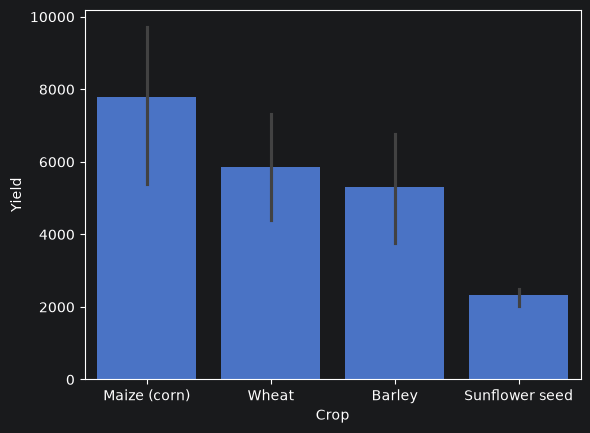

In [7]:
sns.barplot(data=crop_yields, x='Crop', y='Yield')
plt.show()

#make plot by country by crop from yield data -  Tier 1